# CNM Analysis for p+Pb LHC (5.02 & 8.16 TeV)
This notebook calculates and plots the coherent nuclear matter (CNM) effects (nPDF shadowing, coherent energy loss, and Cronin broadening) for charmonia in p+Pb collisions at LHC energies.

**Components:**
- **nPDF**: Shadowing using EPPS21
- **ELoss**: Coherent energy loss (Arleo-Peigné)
- **Broad**: Cronin pT broadening
- **ELoss + Broad**: Product of ELoss and Broadening factors
- **Total CNM**: nPDF × (ELoss × Broad)

**Styling**: Publication-ready plots with consistent color schemes.

## Setup & Calc

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dataclasses import replace

# Add paths for custom modules
sys.path.append('..')
sys.path.append('../eloss_code')
sys.path.append('../cnm_combine')
sys.path.append('../npdf_code')

from cnm_combine_fast_nuclabs import CNMCombineFast
from particle import Particle
from system_configs import LHCConfig as Config
from npdf_nuclAbs_centrality_dAu import NuclearAbsorption

import warnings
warnings.filterwarnings('ignore')

# Constants and Knobs
SAVE_PDF = True
SAVE_CSV = True
DPI = 150
ALPHA_BAND = 0.25
STEP_DEFAULT = True

# Absorption knobs (p+Pb)
SIGMA_ABS_CENTRAL = 0.5  # Central value in mb
SIGMA_ABS_LOW = 0.0
SIGMA_ABS_HIGH = 1.0
ABS_MODE = "avg_TA"

# Color Scheme
COLORS = {
    'abs_only': 'tab:green',
    'npdf': '#E69F00',
    'eloss': "#EC5B5B",
    'broad': "#2B2BEF",
    'eloss_broad': "#020202",
    'cnm': 'gray',
    'cnm_abs': '#7B2CBF',
}

COMP_LABELS = {
    'abs_only': 'Absorption Only',
    'npdf': 'nPDF (EPPS21)',
    'eloss': 'Energy Loss',
    'broad': r'$p_T$ Broadening',
    'eloss_broad': r'ELoss + $p_T$ Broad',
    'cnm': 'Total CNM',
    'cnm_abs': 'CNM + Abs',
}

print("Setup complete.")


Setup complete.


In [2]:
def step_from_centers(xc, yc):
    """Construct edges for ax.step(where='post') from centers"""
    xc = np.asarray(xc, float)
    yc = np.asarray(yc, float)
    if xc.size < 2:
        dx = 1.0
        return np.array([xc[0]-0.5*dx, xc[0]+0.5*dx], float), np.array([yc[0], yc[0]], float)
    dx = xc[1] - xc[0]
    edges = np.concatenate([xc - 0.5*dx, [xc[-1] + 0.5*dx]])
    vals = np.concatenate([yc, [yc[-1]]])
    return edges, vals

def apply_pub_style(ax, xlim, ylim, xlabel, ylabel, tag=None, note=None):
    """Standardize plot appearance"""
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.axhline(1.0, color='k', ls='-', lw=0.8, alpha=0.5)
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    if tag:
        ax.text(0.95, 0.95, tag, transform=ax.transAxes, ha='right', va='top', fontsize=12, fontweight='bold')
    if note:
        ax.text(0.05, 0.05, note, transform=ax.transAxes, ha='left', va='bottom', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

def plot_component_band(ax, x_cent, bands, comp, tag, step=True):
    Rc_dict, Rlo_dict, Rhi_dict = bands[comp]
    xc = np.asarray(x_cent)
    yc = np.asarray(Rc_dict[tag])
    yl = np.asarray(Rlo_dict[tag])
    yh = np.asarray(Rhi_dict[tag])
    yl2 = np.minimum(yl, yh)
    yh2 = np.maximum(yl, yh)
    yl2 = np.minimum(yl2, yc)
    yh2 = np.maximum(yh2, yc)
    color = COLORS.get(comp, 'black')
    label = COMP_LABELS.get(comp, comp)
    if step:
        xe, ye = step_from_centers(xc, yc)
        _, yel = step_from_centers(xc, yl2)
        _, yeh = step_from_centers(xc, yh2)
        ax.step(xe, ye, where='post', color=color, lw=1.7, label=label)
        ax.fill_between(xe, yel, yeh, step='post', color=color, alpha=ALPHA_BAND, lw=0)
    else:
        ax.plot(xc, yc, color=color, lw=1.7, label=label)
        ax.fill_between(xc, yl2, yh2, color=color, alpha=ALPHA_BAND, lw=0)

# ---- Absorption helpers ----

def ncoll_by_cent_bins(gl, cent_bins):
    kind = "dA" if getattr(gl.spec, "system", "pA") == "dA" else "pA"
    fn = gl.ncoll_mean_bin_dA_optical if kind == "dA" else gl.ncoll_mean_bin_pA_optical
    ncoll = [fn(a/100.0, b/100.0) for (a,b) in cent_bins]
    ncoll_mb = fn(0.0, 1.0)
    return np.asarray(ncoll, float), float(ncoll_mb)

def compute_avg_survival_bin(gl, c0, c1, sigma_mb, mode, nb=24):
    abs_obj = NuclearAbsorption(mode=mode, sigma_abs_mb=sigma_mb)
    kind = "dA" if getattr(gl.spec, "system", "pA") == "dA" else "pA"
    ps = np.linspace(c0/100.0, c1/100.0, nb)
    vals = []
    for p in ps:
        b_val = gl.b_from_percentile(float(p), kind=kind)
        vals.append(abs_obj.survival(gl, b_val))
    return float(np.mean(vals))

def get_green_constants(gl, cent_bins, sigma_low, sigma_cent, sigma_high, mode):
    tag_map = {f"{int(c0)}-{int(c1)}%": (c0, c1) for (c0,c1) in cent_bins}
    bin_res = {}
    for tag, (c0, c1) in tag_map.items():
        sc = compute_avg_survival_bin(gl, c0, c1, sigma_cent, mode)
        sl = compute_avg_survival_bin(gl, c0, c1, sigma_low, mode)
        sh = compute_avg_survival_bin(gl, c0, c1, sigma_high, mode)
        bin_res[tag] = (sc, min(sl, sh), max(sl, sh))
    ncoll, _ = ncoll_by_cent_bins(gl, cent_bins)
    widths = np.array([c1-c0 for (c0,c1) in cent_bins])
    w_mb = ncoll * widths
    tags_ordered = [f"{int(c0)}-{int(c1)}%" for (c0,c1) in cent_bins]
    vals_c = [bin_res[t][0] for t in tags_ordered]
    vals_lo = [bin_res[t][1] for t in tags_ordered]
    vals_hi = [bin_res[t][2] for t in tags_ordered]
    mb_c = np.average(vals_c, weights=w_mb)
    mb_lo = np.average(vals_lo, weights=w_mb)
    mb_hi = np.average(vals_hi, weights=w_mb)
    bin_res['MB'] = (float(mb_c), float(mb_lo), float(mb_hi))
    return bin_res

def flat_band_from_green_map(x_cent, green_map):
    Rc, Rlo, Rhi = {}, {}, {}
    for tag, (gc, glo, ghi) in green_map.items():
        Rc[tag] = np.full_like(x_cent, float(gc), dtype=float)
        Rlo[tag] = np.full_like(x_cent, float(glo), dtype=float)
        Rhi[tag] = np.full_like(x_cent, float(ghi), dtype=float)
    return Rc, Rlo, Rhi


In [3]:
## Compute For later plotting
energies = [5.02, 8.16]

components_base = ['npdf', 'eloss', 'broad', 'eloss_broad', 'cnm']
components_abs  = ['abs_only', 'cnm_abs']
components_plot = ['abs_only', 'npdf', 'eloss', 'broad', 'eloss_broad', 'cnm', 'cnm_abs']

cnm_by_E    = {}
cnm_abs_by_E = {}
green_map_by_E = {}
outdir_by_E = {}

res_y   = {}
res_pt  = {}
res_cent = {}


In [4]:
for energy in energies:
    print(f"\n[LOAD] {energy} TeV ...")
    outdir = Path(f'../outputs/cnm_combined/LHC_{energy}TeV')
    outdir.mkdir(parents=True, exist_ok=True)
    outdir_by_E[energy] = outdir

    particle = Particle(family='charmonia', state='avg')

    cnm = CNMCombineFast.from_defaults(
        energy=str(energy), family='charmonia', particle_state='avg',
        alpha_s_mode='constant', alpha0=0.5,
        cent_bins=Config.cent_bins_plotting,
        enable_absorption=False,
    )
    cnm_by_E[energy] = cnm

    cnm_abs = CNMCombineFast.from_defaults(
        energy=str(energy), family='charmonia', particle_state='avg',
        alpha_s_mode='constant', alpha0=0.5,
        cent_bins=Config.cent_bins_plotting,
        enable_absorption=True,
        abs_sigma_mb=SIGMA_ABS_CENTRAL,
        abs_mode=ABS_MODE,
    )
    cnm_abs_by_E[energy] = cnm_abs

    green_map_by_E[energy] = get_green_constants(
        cnm_abs.gl, cnm_abs.cent_bins,
        SIGMA_ABS_LOW, SIGMA_ABS_CENTRAL, SIGMA_ABS_HIGH, ABS_MODE,
    )
    print("Loading and calc done.")



[LOAD] 5.02 TeV ...
Loading and calc done.

[LOAD] 8.16 TeV ...
Loading and calc done.


## 1. $R_{pA}$ vs y (Integrated over pT [0, 10.0] GeV)

In [5]:
for energy in energies:
    print(f"[CALC y] {energy} TeV ...")
    cnm = cnm_by_E[energy]
    cnm_abs = cnm_abs_by_E[energy]
    y_edges = np.linspace(-5.0, 5.0, 21)

    y_cent, labels, final_bands_y = cnm.cnm_vs_y(
        y_edges,
        pt_range_avg=Config.pt_range_integrated,
        components=components_base,
        include_mb=True,
    )

    _, _, bands_y_abs = cnm_abs.cnm_vs_y(
        y_edges,
        pt_range_avg=Config.pt_range_integrated,
        components=['cnm'],
        include_mb=True,
    )

    abs_band_y = flat_band_from_green_map(y_cent, green_map_by_E[energy])
    final_bands_y['abs_only'] = abs_band_y
    final_bands_y['cnm_abs']  = bands_y_abs['cnm']

    res_y[energy] = (y_cent, labels, final_bands_y, y_edges)


[CALC y] 5.02 TeV ...
[CALC y] 8.16 TeV ...


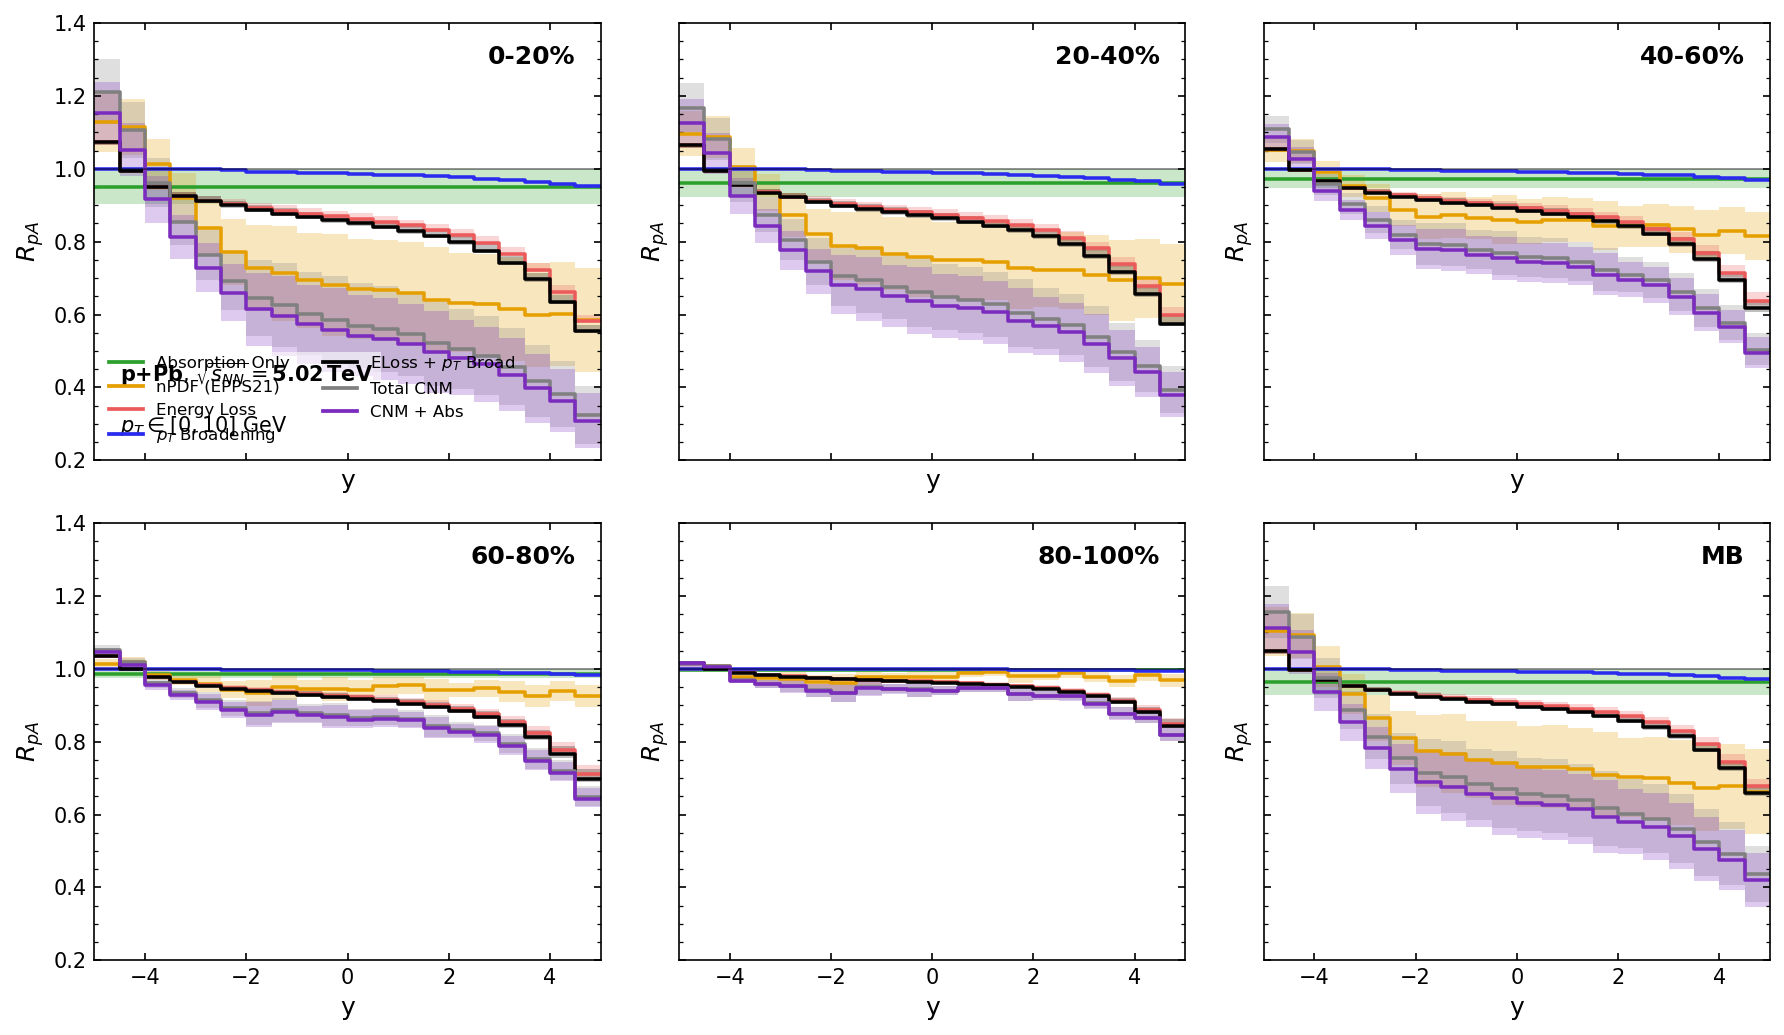

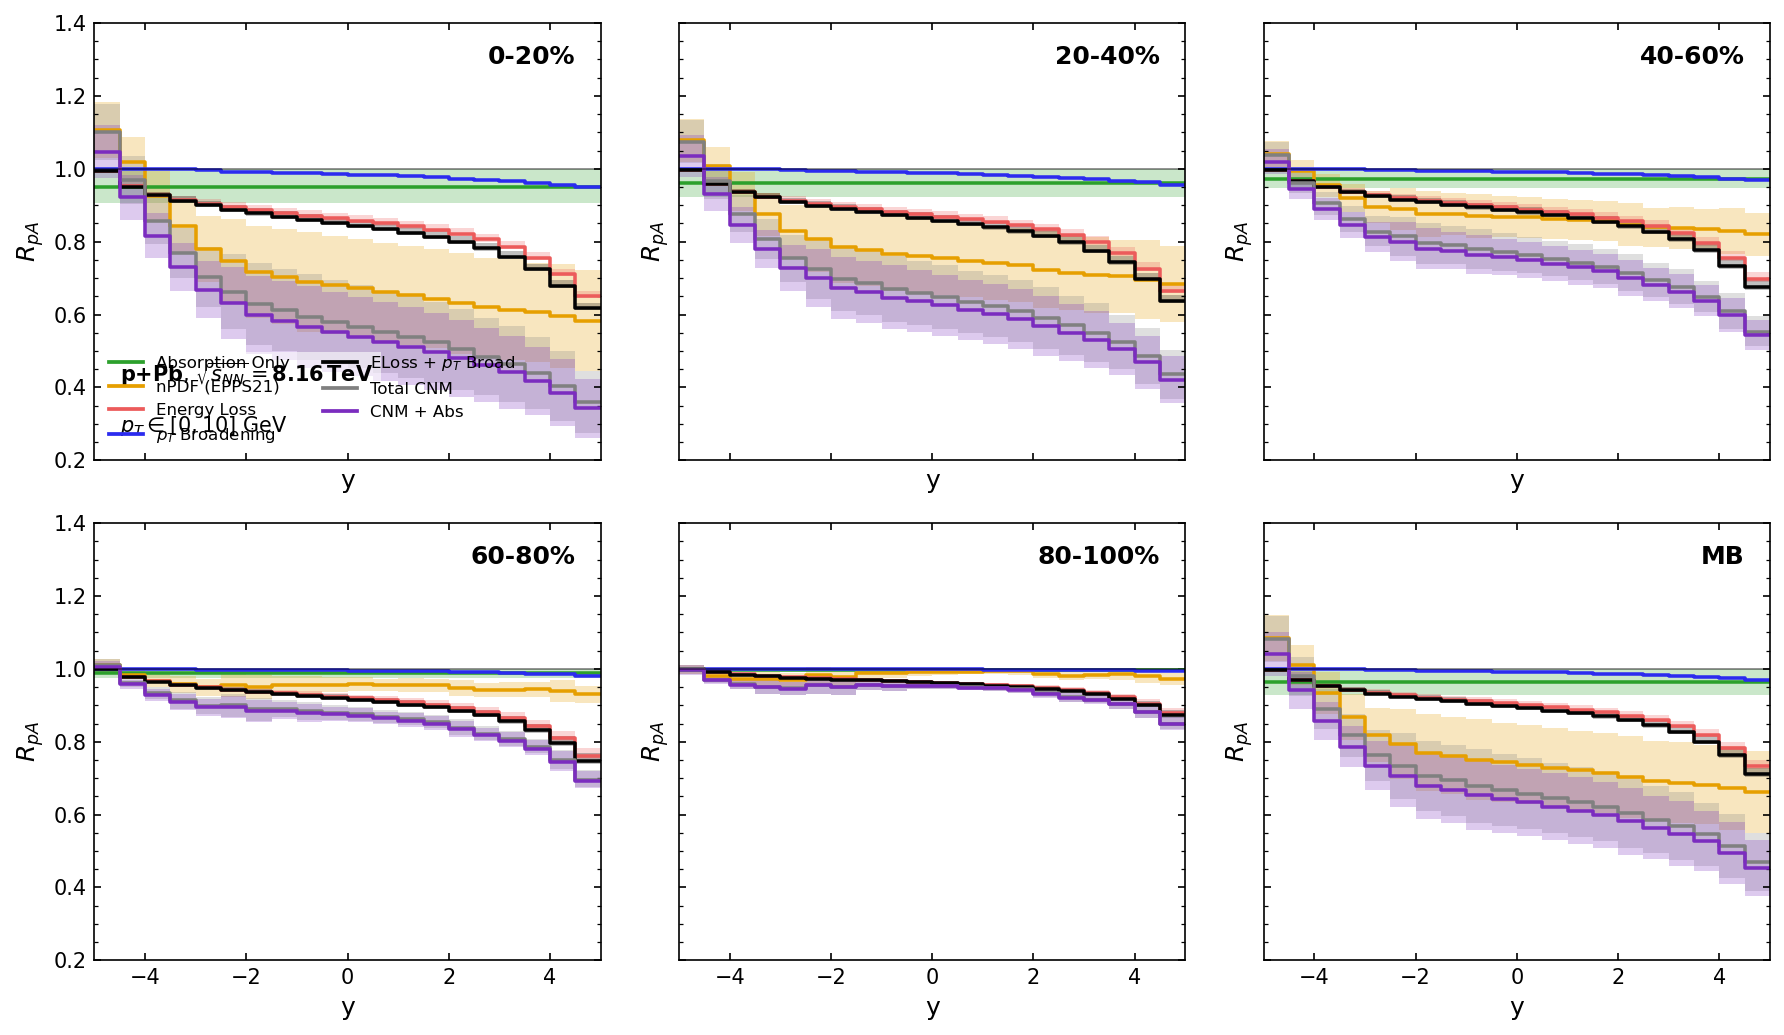

In [6]:
for energy in energies:
    outdir = outdir_by_E[energy]
    y_cent, labels, final_bands_y, y_edges = res_y[energy]

    tags_to_plot = labels + ['MB']
    n_pan = len(tags_to_plot)
    n_cols = 3
    n_rows = int(np.ceil(n_pan / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), dpi=DPI, sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    note_y = rf"$\mathbf{{p{{+}}Pb}}$, $\sqrt{{s_{{NN}}}} = \mathbf{{{energy}}}\,\mathbf{{TeV}}$" + "\n\n" + r"$p_T \in [0,10]$ GeV"
    for i, tag in enumerate(tags_to_plot):
        ax = axes[i]
        for comp in components_plot:
            plot_component_band(ax, y_cent, final_bands_y, comp, tag, step=STEP_DEFAULT)
        apply_pub_style(ax, (-5, 5), (0.2, 1.4), 'y', r'$R_{pA}$', tag=tag, note=note_y if i==0 else None)
        if i == 0:
            handles = [plt.Line2D([], [], color=COLORS[c], lw=1.8, label=COMP_LABELS[c]) for c in components_plot]
            ax.legend(handles=handles, loc='lower left', fontsize=8, ncol=2, frameon=False)

    for k in range(n_pan, len(axes)):
        fig.delaxes(axes[k])

    fig.tight_layout()
    if SAVE_PDF:
        fig.savefig(outdir / f'RpA_vs_y_all_components_{energy}TeV.pdf', bbox_inches='tight')
    plt.show()


## 2. $R_{pA}$ vs $p_T$ in Rapidity Windows

In [7]:
for energy in energies:
    print(f"[CALC pT] {energy} TeV ...")
    cnm = cnm_by_E[energy]
    cnm_abs = cnm_abs_by_E[energy]
    res_pt[energy] = {}

    for y_window in Config.rapidity_windows:
        pT_edges = np.arange(0, 20.5, 2.5)
        pT_cent, labels_pt, final_bands_pt = cnm.cnm_vs_pT(
            y_window, pT_edges,
            components=components_base,
            include_mb=True,
        )

        _, _, bands_pt_abs = cnm_abs.cnm_vs_pT(
            y_window, pT_edges,
            components=['cnm'],
            include_mb=True,
        )

        abs_band_pt = flat_band_from_green_map(pT_cent, green_map_by_E[energy])
        final_bands_pt['abs_only'] = abs_band_pt
        final_bands_pt['cnm_abs']  = bands_pt_abs['cnm']

        res_pt[energy][y_window] = (pT_cent, labels_pt, final_bands_pt, pT_edges)
    print("pT calc done.")


[CALC pT] 5.02 TeV ...
pT calc done.
[CALC pT] 8.16 TeV ...
pT calc done.


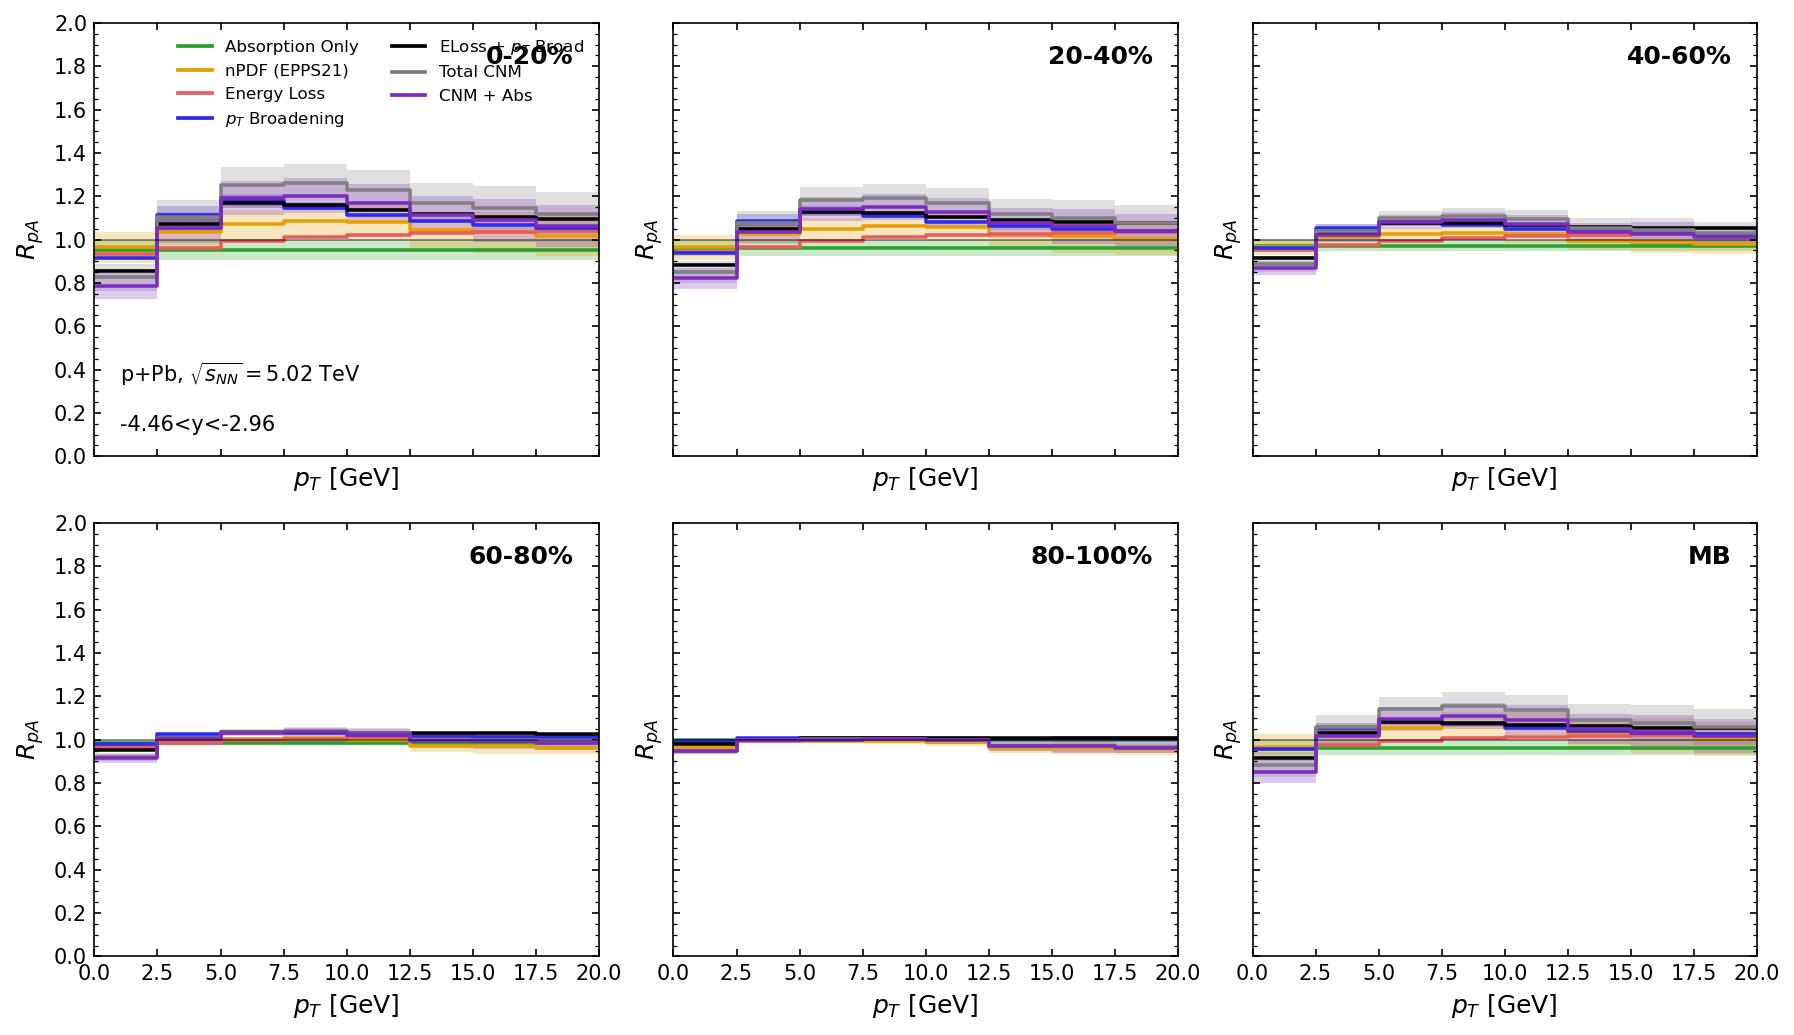

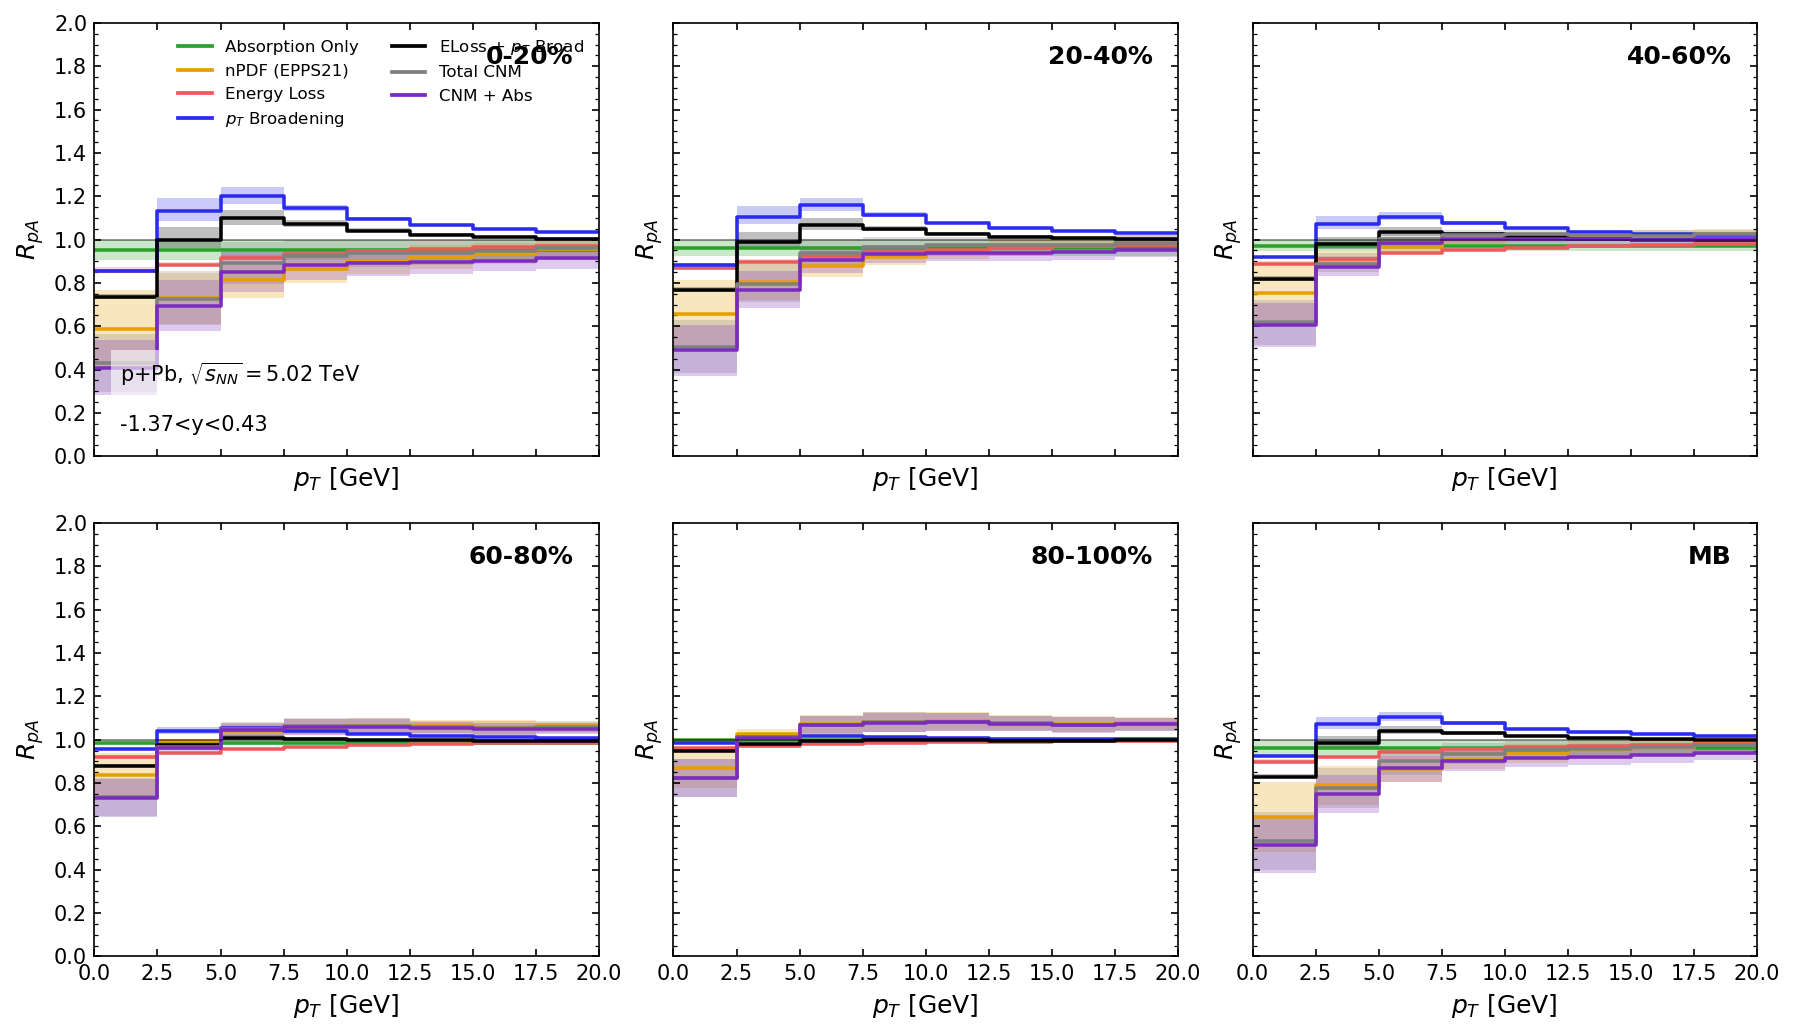

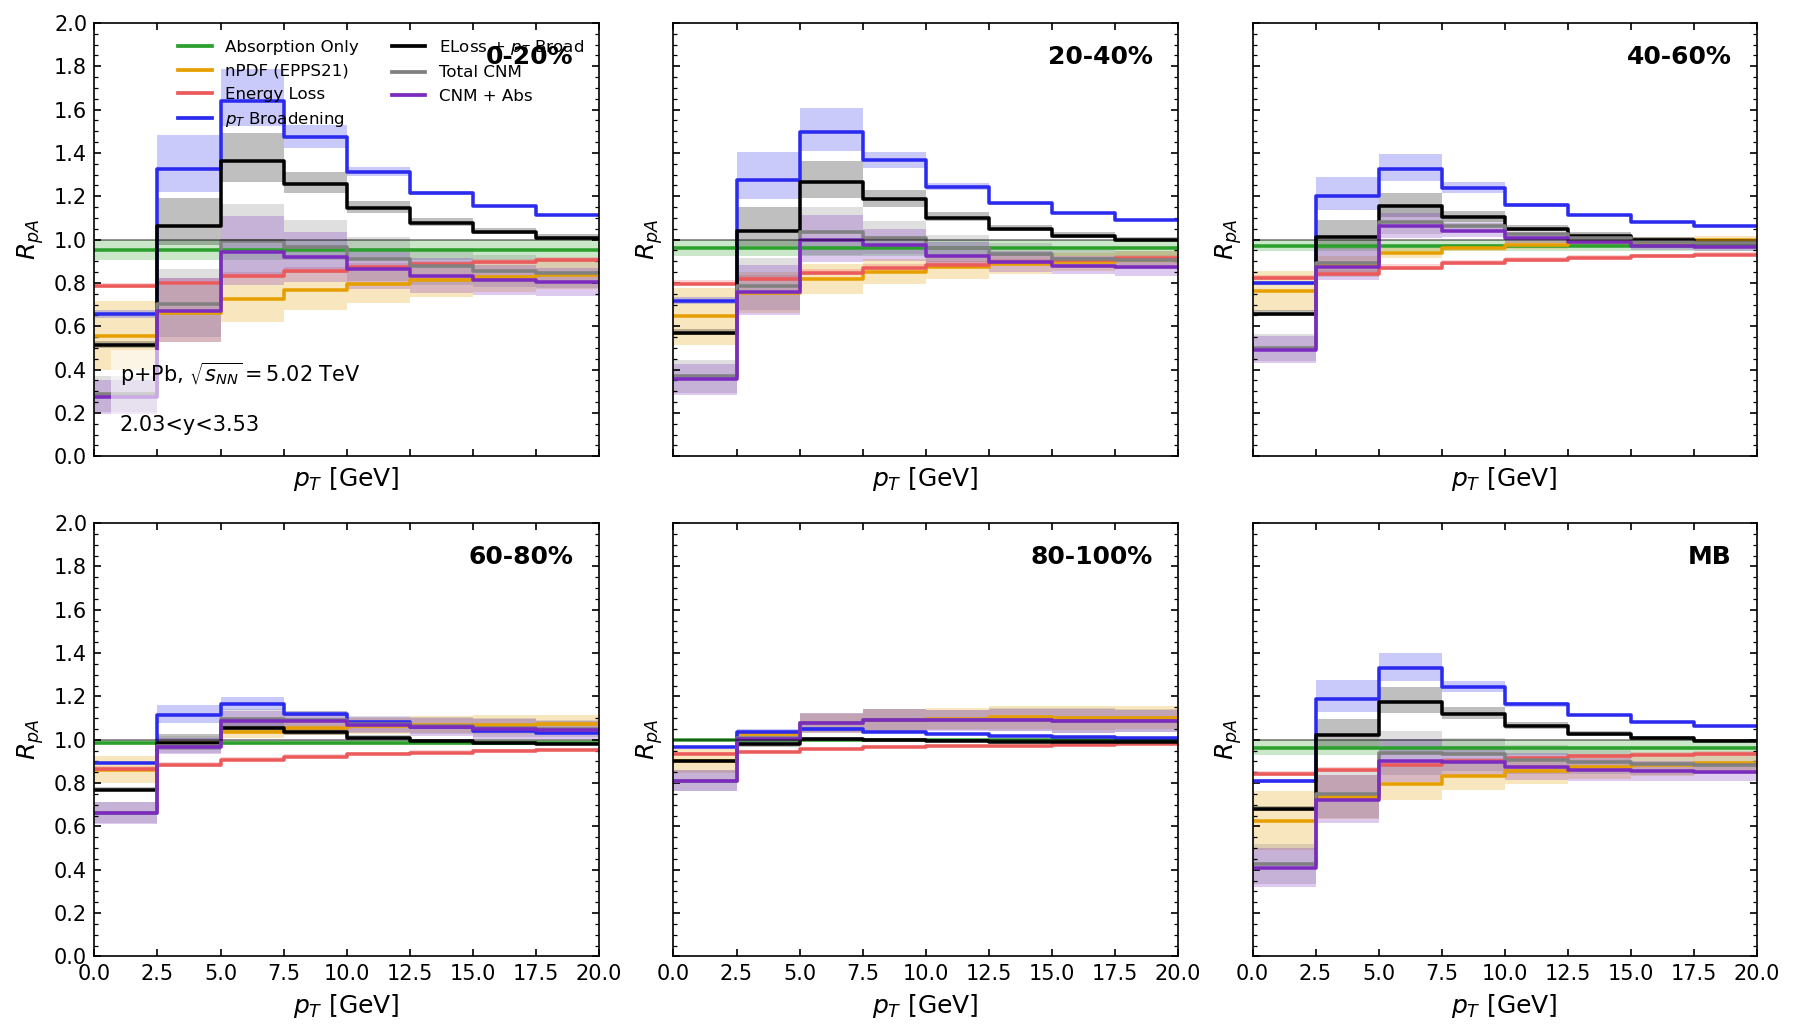

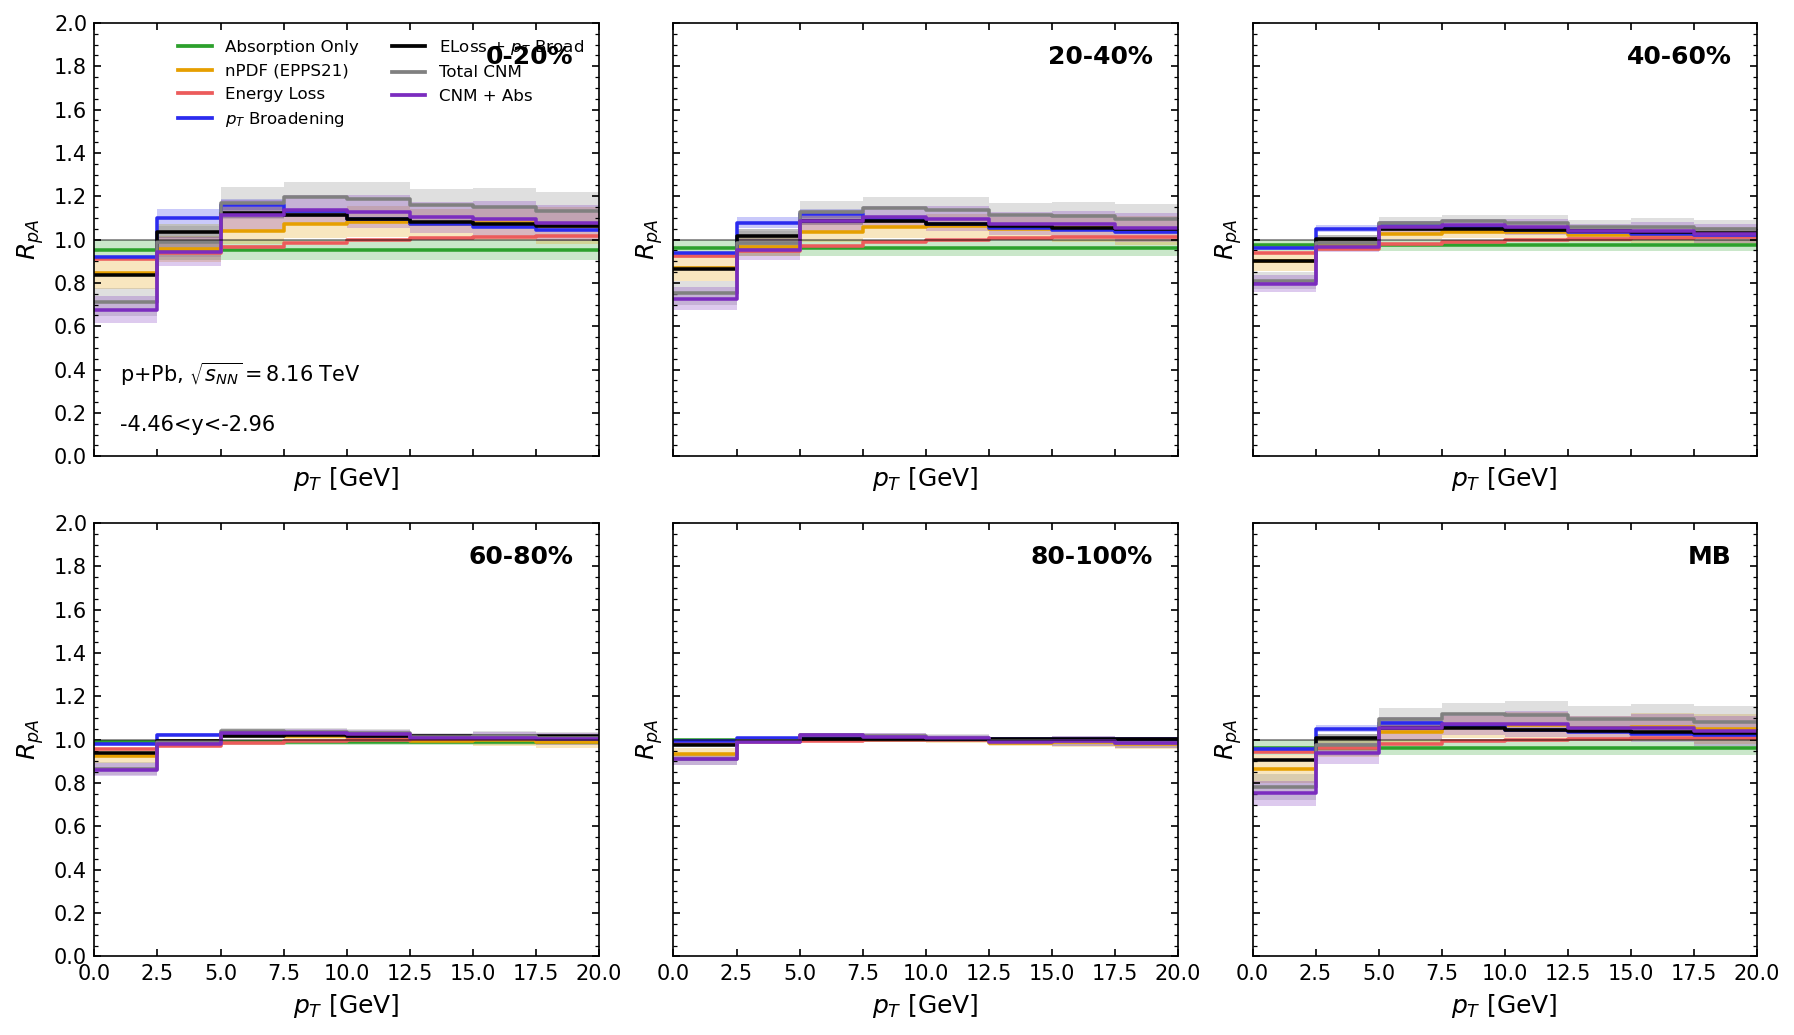

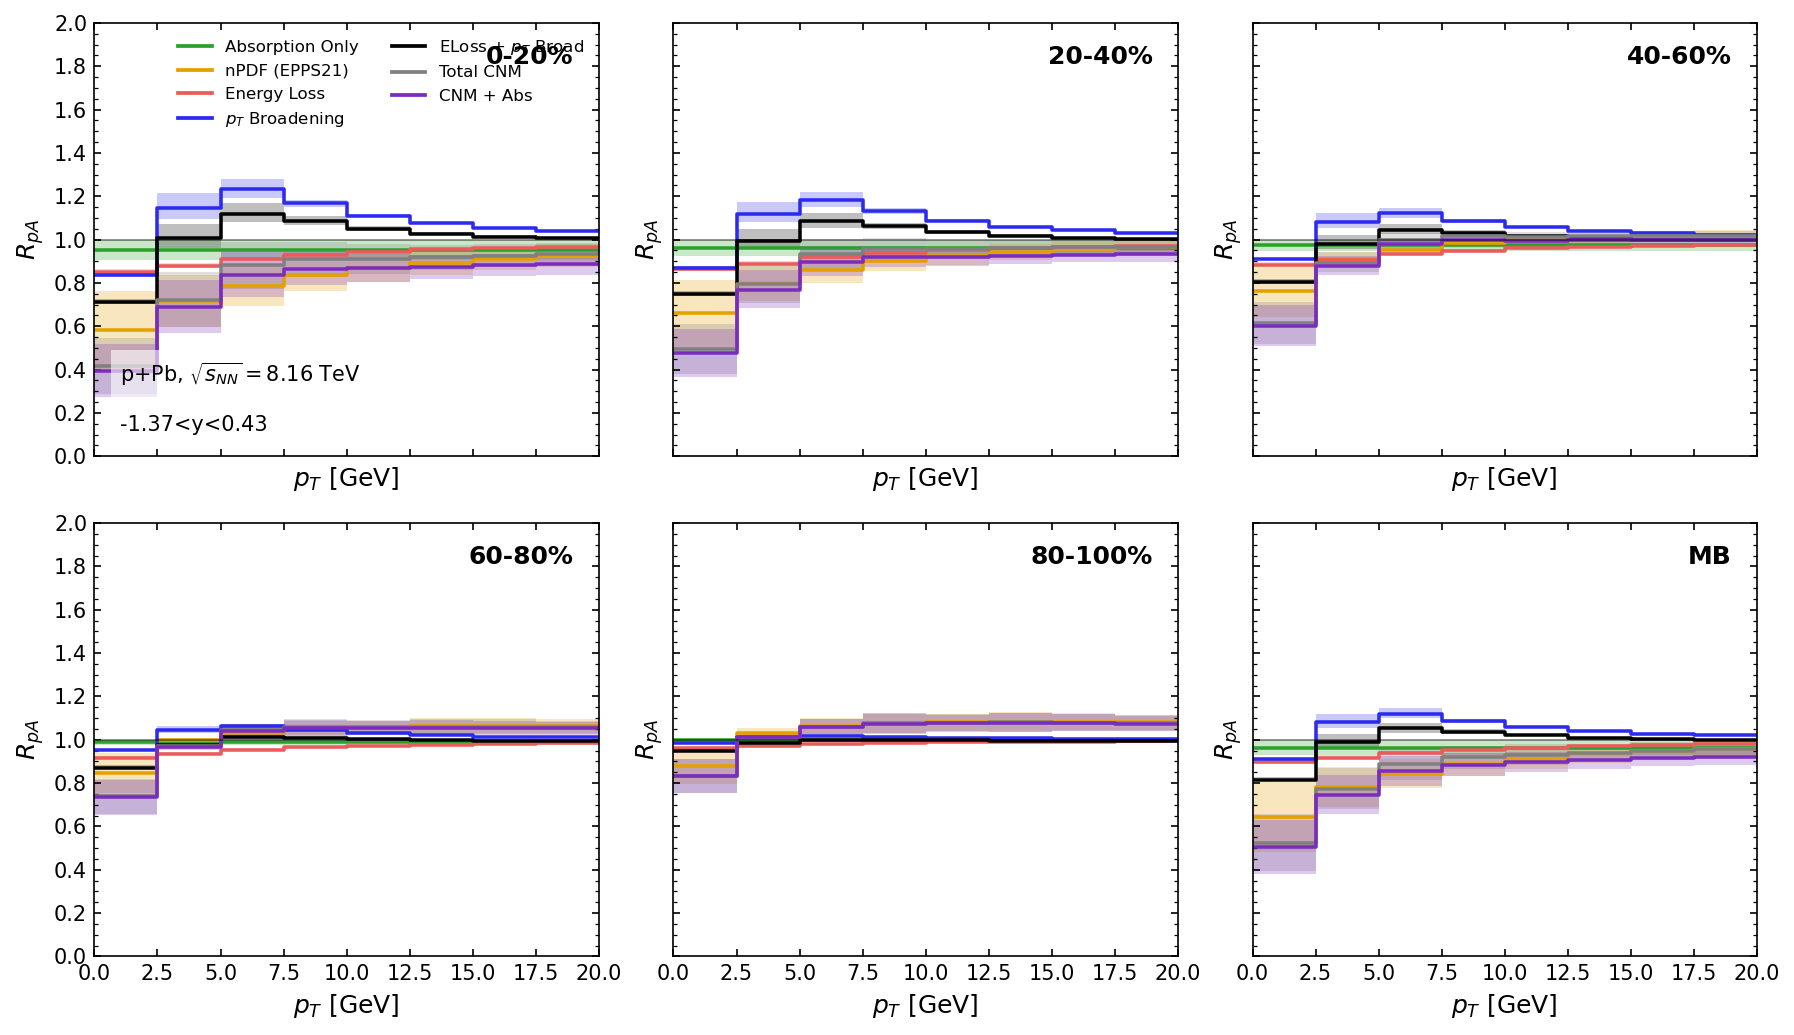

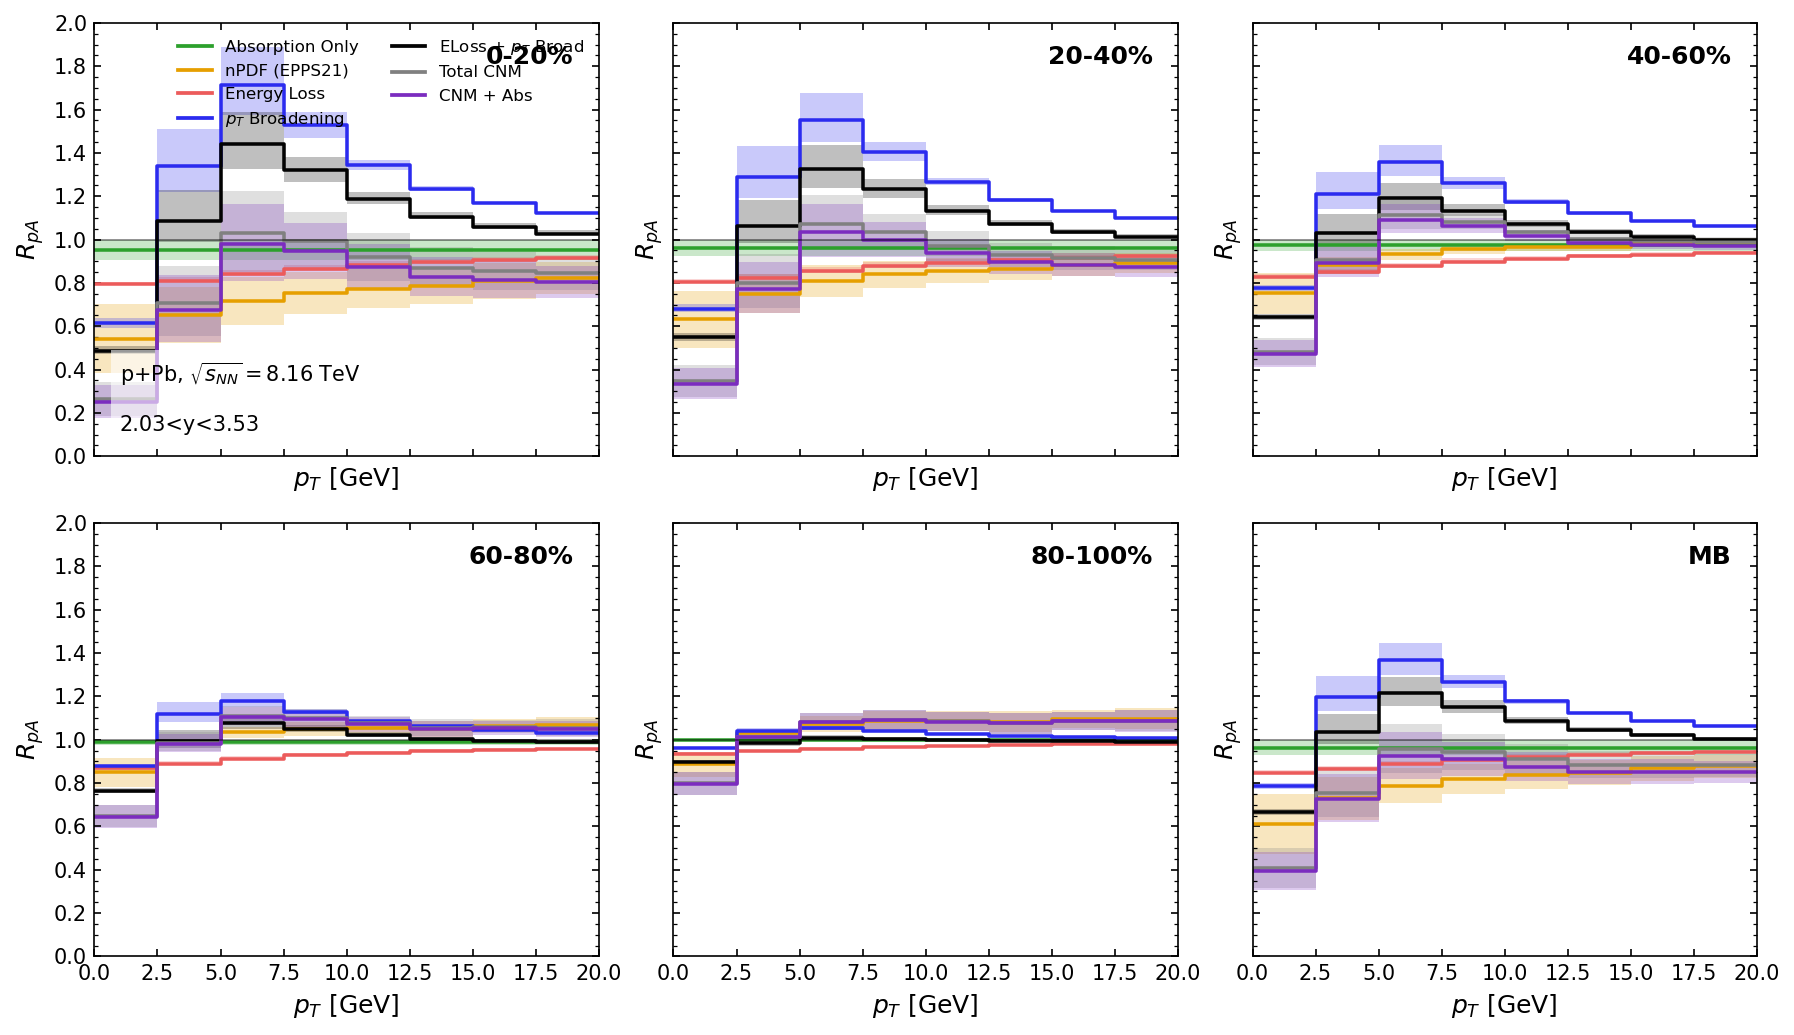

In [8]:
for energy in energies:
    outdir = outdir_by_E[energy]

    _, labels, _, _ = res_y[energy]
    tags_to_plot = labels + ['MB']
    n_pan = len(tags_to_plot)
    n_cols = 3
    n_rows = int(np.ceil(n_pan / n_cols))

    for y_window in Config.rapidity_windows:
        y0, y1 = y_window
        pT_cent, labels_pt, final_bands_pt, pT_edges = res_pt[energy][y_window]

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), dpi=DPI, sharex=True, sharey=True)
        axes = np.atleast_1d(axes).ravel()

        note_pt = rf"p+Pb, $\sqrt{{s_{{NN}}}} = {energy}$ TeV" + "\n\n" + f"{y0}<y<{y1}"
        for i, tag in enumerate(tags_to_plot):
            ax = axes[i]
            for comp in components_plot:
                plot_component_band(ax, pT_cent, final_bands_pt, comp, tag, step=STEP_DEFAULT)
            apply_pub_style(ax, (0., 20), (0.0, 2.0), '$p_T$ [GeV]', r'$R_{pA}$', tag=tag, note=note_pt if i==0 else None)
            if i == 0:
                handles = [plt.Line2D([], [], color=COLORS[c], lw=1.8, label=COMP_LABELS[c]) for c in components_plot]
                ax.legend(handles=handles, loc='upper right', fontsize=8, ncol=2, frameon=False)

        for k in range(n_pan, len(axes)):
            fig.delaxes(axes[k])

        fig.tight_layout()
        safe_w = f"{y0}to{y1}".replace(' ','')
        if SAVE_PDF:
            fig.savefig(outdir / f'RpA_vs_pt_all_components_{safe_w}_{energy}TeV.pdf', bbox_inches='tight')
        plt.show()


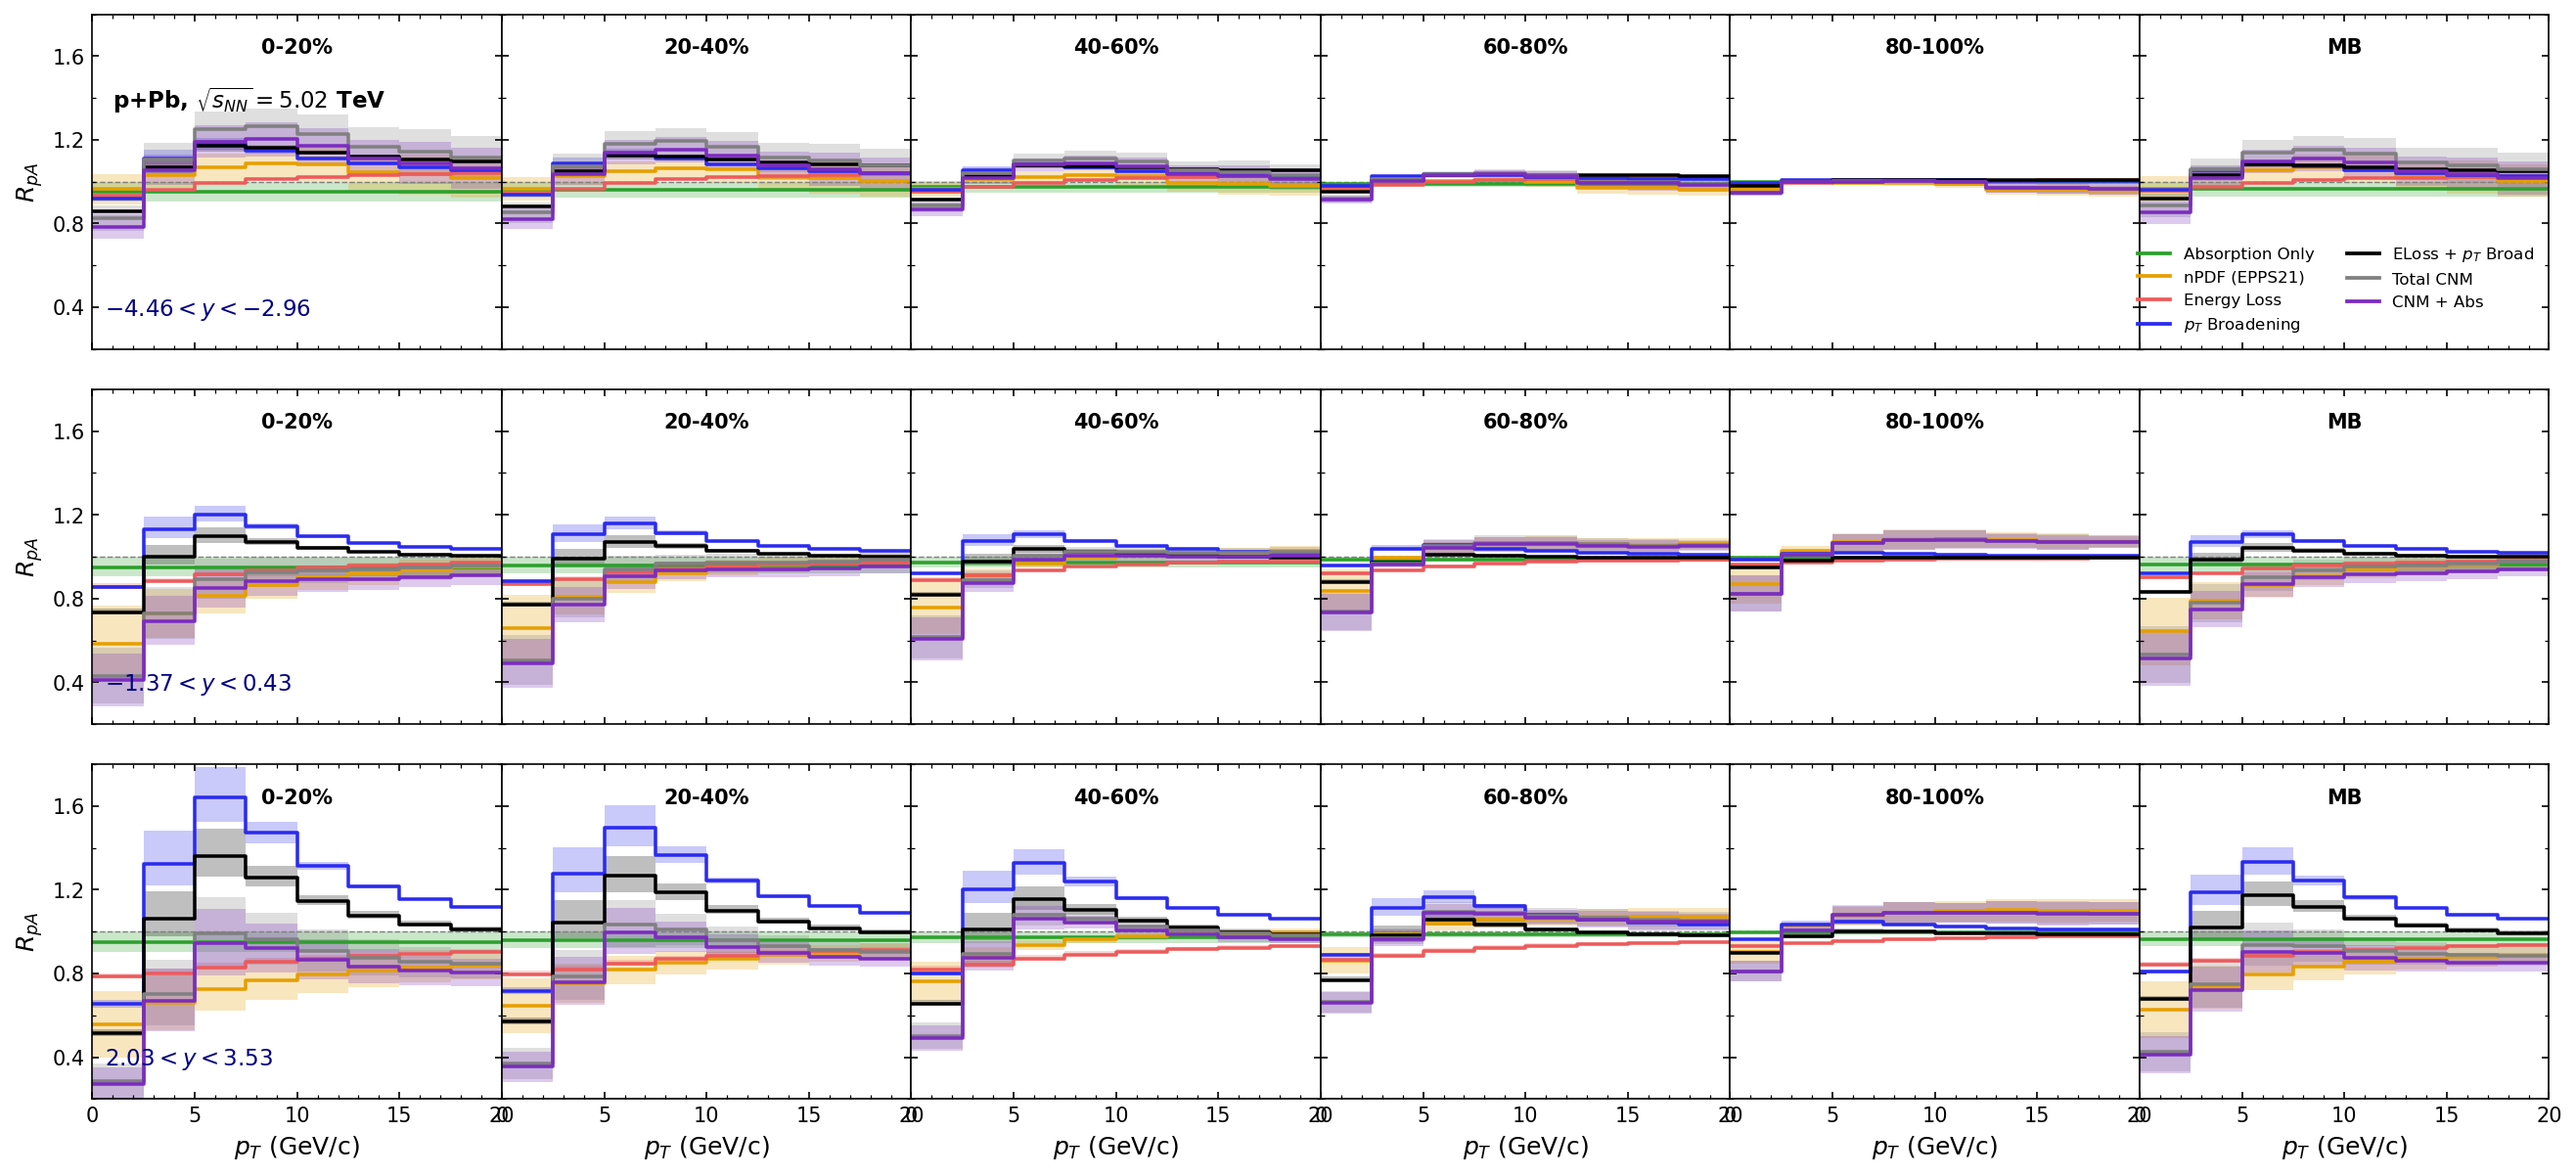

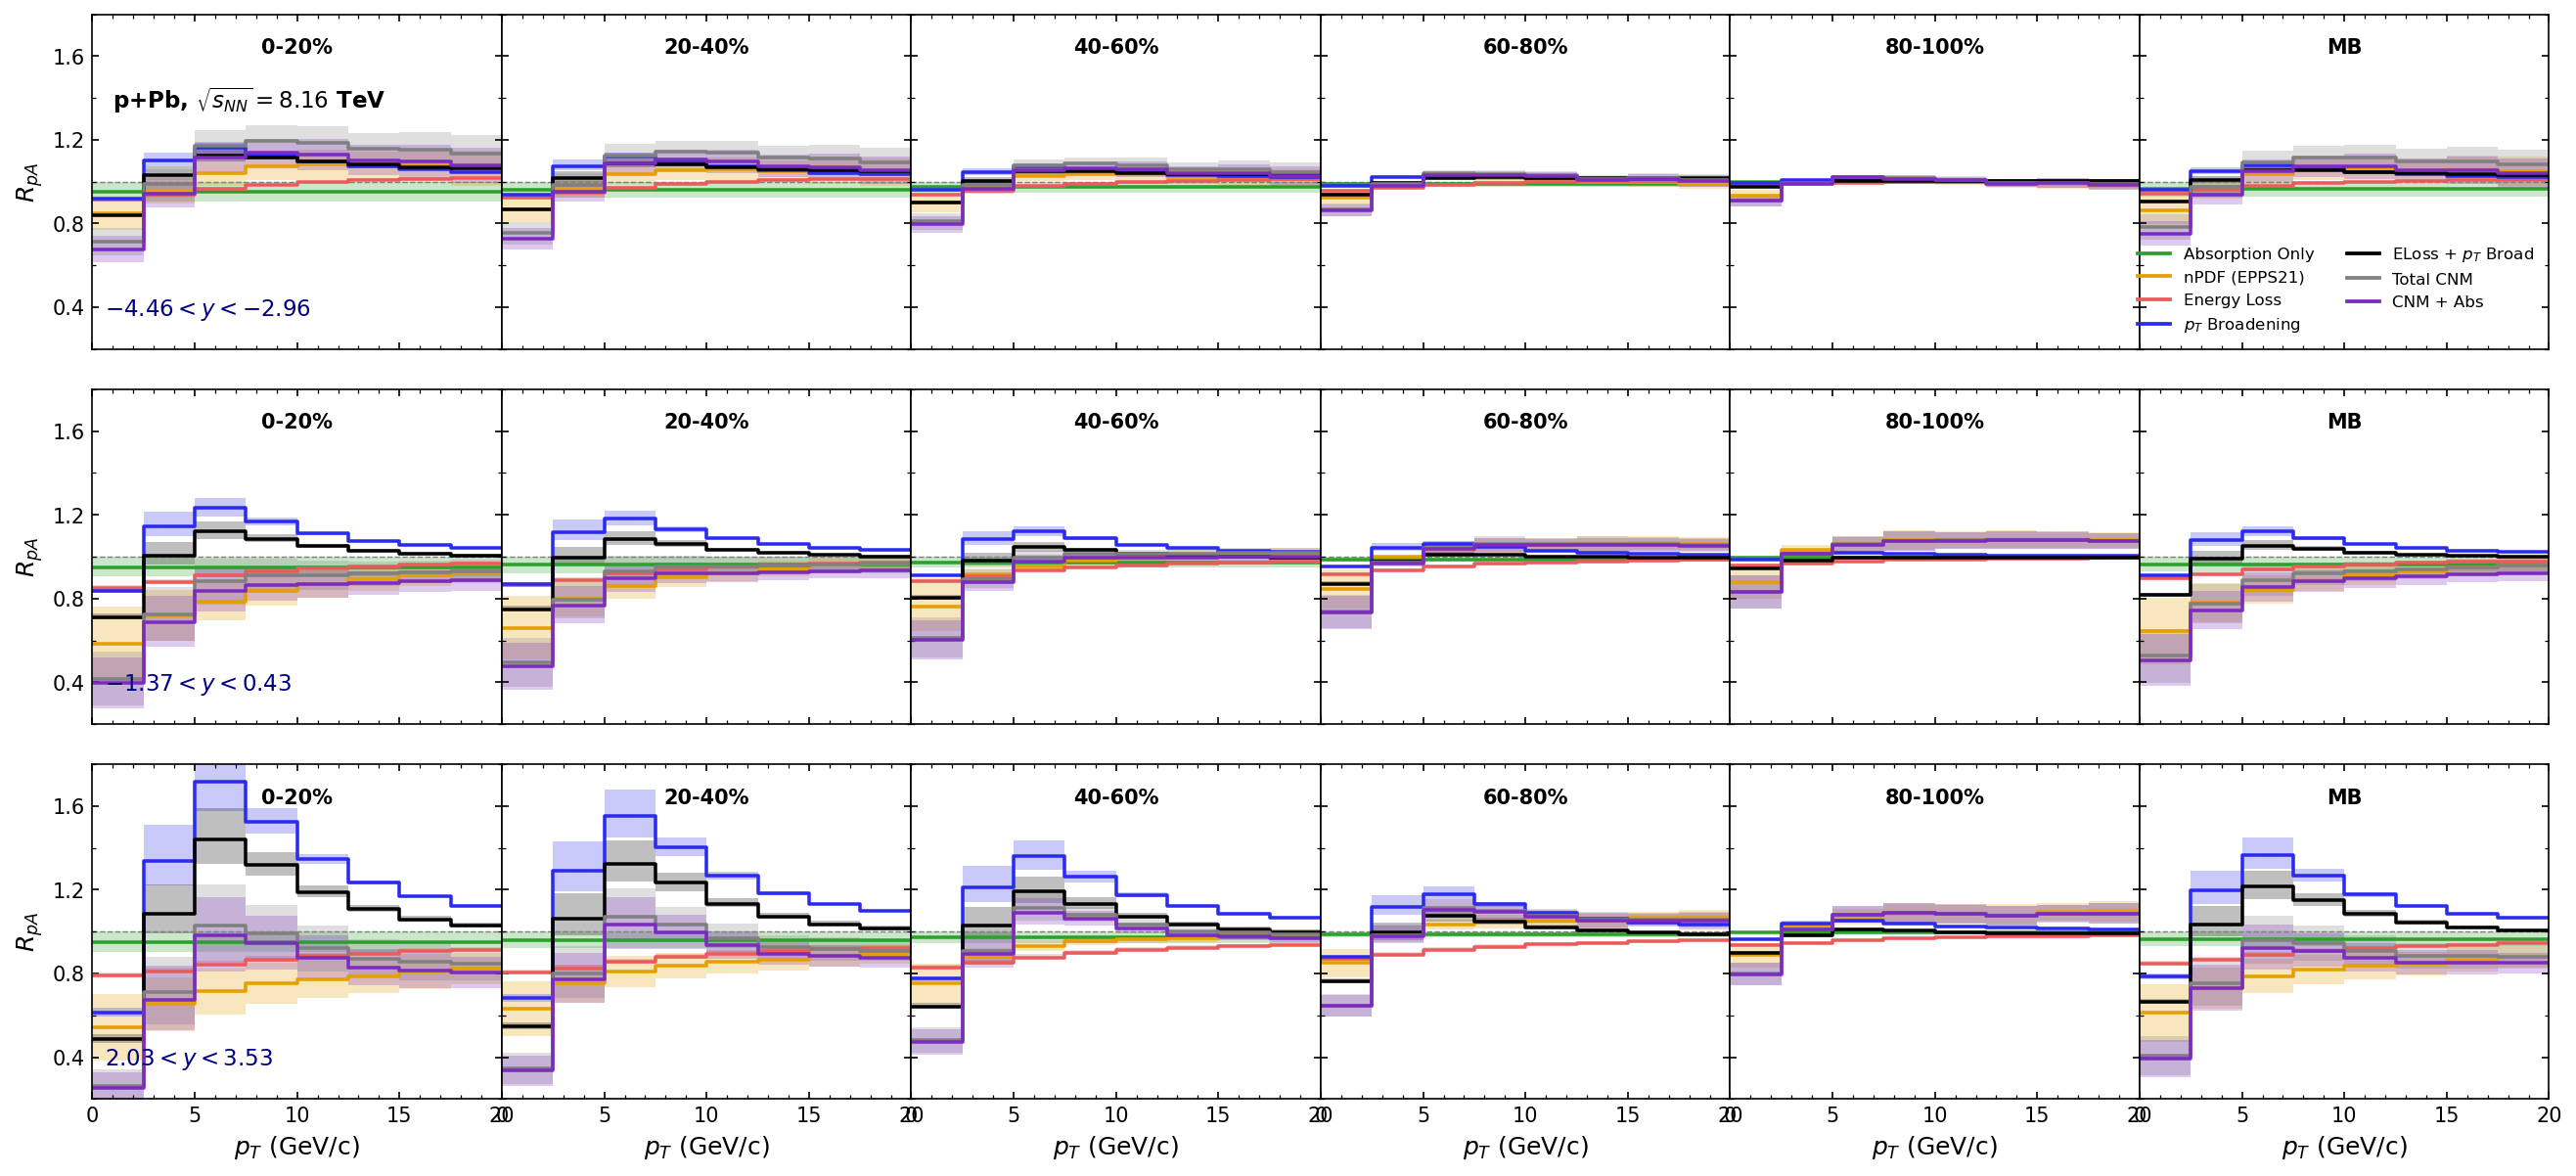

In [15]:
import matplotlib.ticker as ticker

# Components to draw
components_plot = ['abs_only', 'npdf', 'eloss', 'broad', 'eloss_broad', 'cnm', 'cnm_abs']

for energy in energies:
    outdir = outdir_by_E[energy]

    # use tags from res_y
    _, labels, _, _ = res_y[energy]
    tags_to_plot = labels + ['MB']
    n_cols = len(tags_to_plot)
    n_rows = len(Config.rapidity_windows)

    fig, axs = plt.subplots(
        n_rows, n_cols,
        figsize=(3.6 * n_cols, 3.2 * n_rows),
        dpi=DPI,
        sharex=True, sharey=True,
        gridspec_kw={"wspace": 0.0, "hspace": 0.12}
    )
    axs = np.atleast_2d(axs)

    # iterate rows = rapidity windows
    for irow, y_window in enumerate(Config.rapidity_windows):
        y0, y1 = y_window
        pT_cent, labels_pt, final_bands_pt, pT_edges = res_pt[energy][y_window]

        for jcol, tag in enumerate(tags_to_plot):
            ax = axs[irow, jcol]
            for comp in components_plot:
                plot_component_band(ax, pT_cent, final_bands_pt, comp, tag, step=STEP_DEFAULT)

            ax.axhline(1.0, color="gray", lw=0.7, ls="--", zorder=1)
            ax.set_xlim(0, 20)
            ax.set_ylim(0.2, 1.8)
            ax.tick_params(direction="in", which="both", top=True, right=True, labelsize=10)
            ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

            # centrality tag
            ax.text(0.5, 0.93, "MB" if tag == "MB" else tag,
                    transform=ax.transAxes, ha="center", va="top",
                    fontsize=10, fontweight="bold")

            # rapidity tag on leftmost column
            if jcol == 0:
                ax.text(0.03, 0.08, rf"${y0}<y<{y1}$",
                        transform=ax.transAxes, ha="left", va="bottom",
                        fontsize=11, color="navy", fontweight="bold")

            if irow == n_rows - 1:
                ax.set_xlabel(r"$p_T$ (GeV/c)", fontsize=12)
            if jcol == 0:
                ax.set_ylabel(r"$R_{pA}$", fontsize=12)

            # reduce crowding on shared axes
            if irow < n_rows - 1:
                ax.tick_params(labelbottom=False)

        # put system note on first row/first col
        if irow == 0:
            axs[0, 0].text(0.05, 0.72,
                           rf"p+Pb, $\sqrt{{s_{{NN}}}}={energy}$ TeV",
                           transform=axs[0, 0].transAxes,
                           fontsize=11, fontweight="bold")

    # legend
    handles = [plt.Line2D([], [], color=COLORS[c], lw=1.8, label=COMP_LABELS[c]) for c in components_plot]
    axs[0, -1].legend(handles=handles, loc="lower right", fontsize=8, ncol=2, frameon=False)

    fig.tight_layout()
    if SAVE_PDF:
        fig.savefig(outdir / f"RpA_vs_pT_GRID_all_components_{energy}TeV.pdf", bbox_inches="tight")
    plt.show()

## 3. $R_{pA}$ vs Centrality

In [12]:
for energy in energies:
    print(f"[CALC cent] {energy} TeV ...")
    cnm = cnm_by_E[energy]
    cnm_abs = cnm_abs_by_E[energy]
    res_cent[energy] = {}

    for y_window in Config.rapidity_windows:
        y0, y1 = y_window
        base = cnm.cnm_vs_centrality((y0, y1), pt_range_avg=Config.pt_range_integrated)
        with_abs = cnm_abs.cnm_vs_centrality((y0, y1), pt_range_avg=Config.pt_range_integrated)

        gmap = green_map_by_E[energy]
        tags = [f"{int(a)}-{int(b)}%" for (a,b) in cnm.cent_bins]
        Rc = [gmap[t][0] for t in tags]
        Rlo= [gmap[t][1] for t in tags]
        Rhi= [gmap[t][2] for t in tags]
        mb_c, mb_lo, mb_hi = gmap['MB']
        abs_only = (np.asarray(Rc,float), np.asarray(Rlo,float), np.asarray(Rhi,float), float(mb_c), float(mb_lo), float(mb_hi))

        final = {}
        for comp in components_base:
            final[comp] = base[comp]
        final['abs_only'] = abs_only
        final['cnm_abs']  = with_abs['cnm']

        res_cent[energy][y_window] = final
    print("Cent calc done.")


[CALC cent] 5.02 TeV ...
Cent calc done.
[CALC cent] 8.16 TeV ...
Cent calc done.


[PLOT cent] 5.02 TeV ...


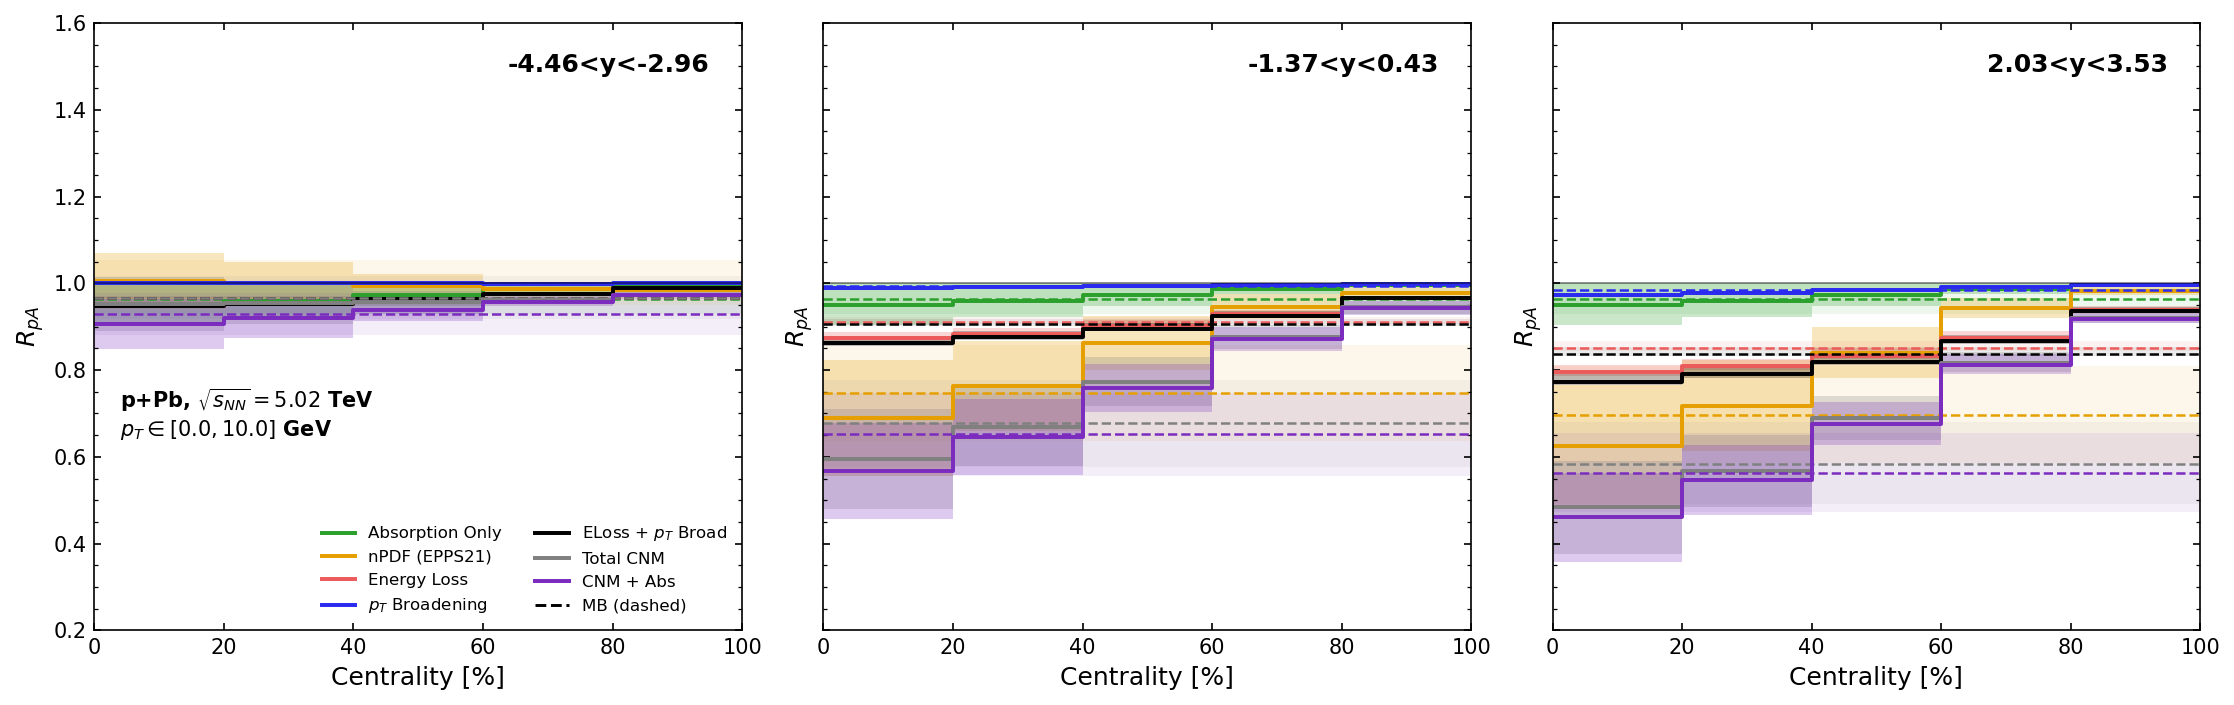

[PLOT cent] 8.16 TeV ...


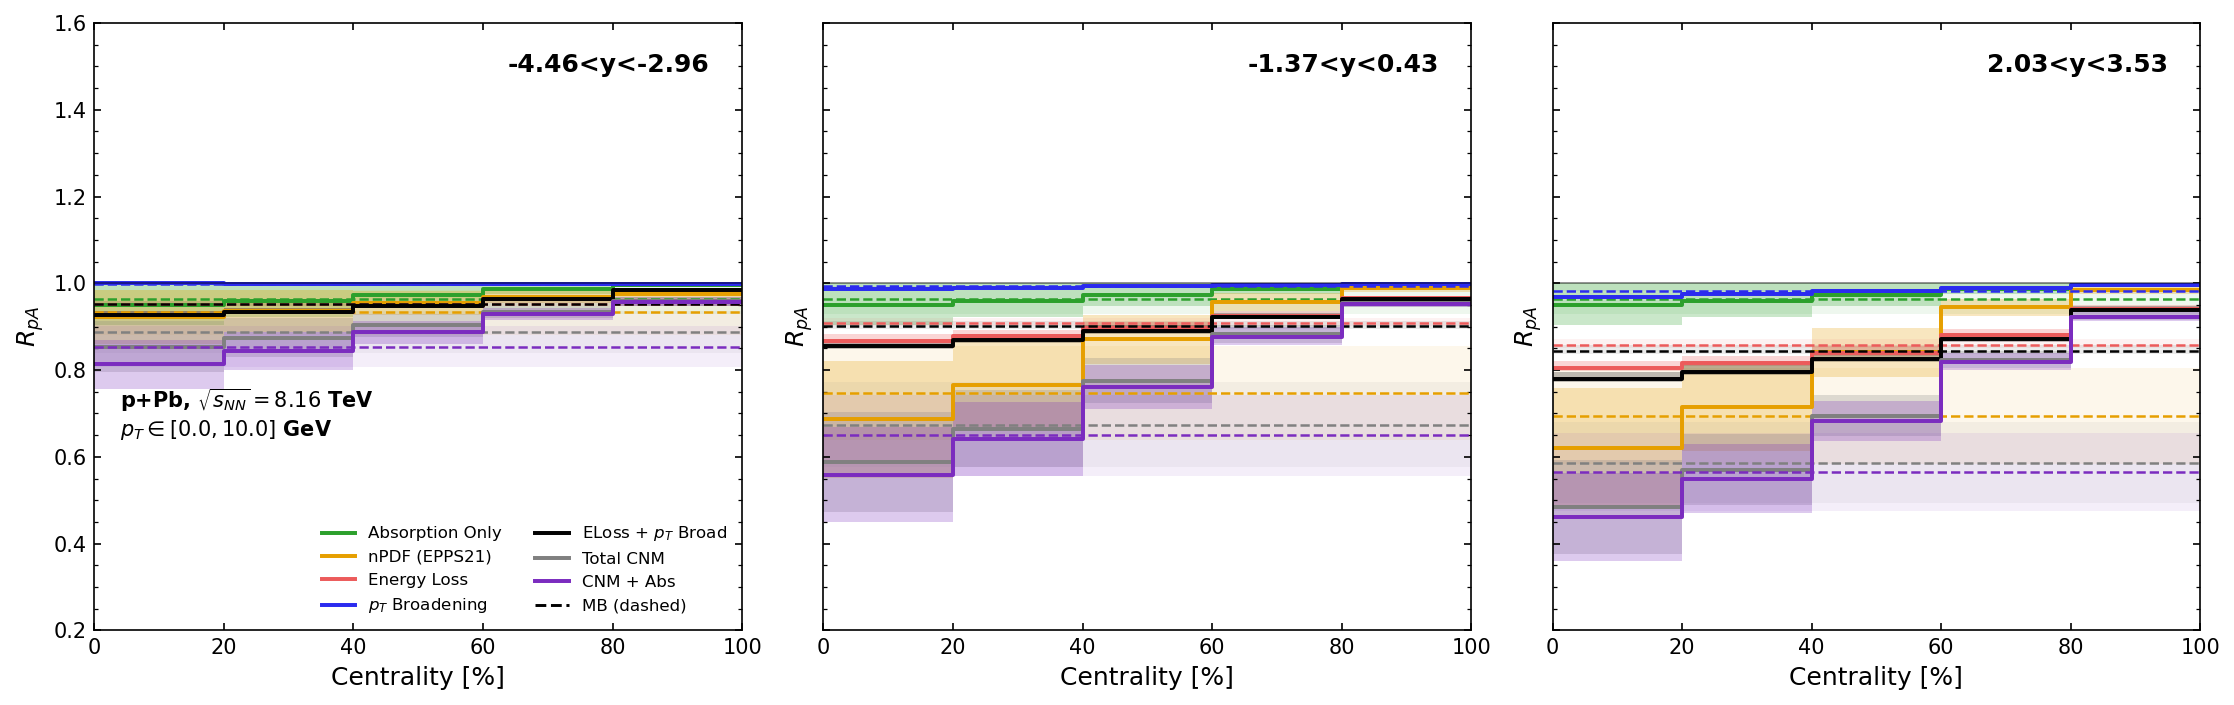

In [13]:
from matplotlib.lines import Line2D

cent_bins = Config.cent_bins_plotting
x_edges = np.array([cent_bins[0][0]] + [b for (_, b) in cent_bins], dtype=float)

def cent_step(yvals):
    yvals = np.asarray(yvals, float)
    return np.r_[yvals, yvals[-1]]

mb_handle = Line2D([0], [0], color="k", lw=1.4, ls="--", label="MB (dashed)")

for energy in energies:
    outdir = outdir_by_E[energy]
    print(f"[PLOT cent] {energy} TeV ...")
    fig, axes = plt.subplots(1, len(Config.rapidity_windows), figsize=(15, 4.8), dpi=DPI, sharey=True)
    axes = np.atleast_1d(axes)

    for ax, y_window in zip(axes, Config.rapidity_windows):
        y0, y1 = y_window
        res_c = res_cent[energy][y_window]
        for comp in components_plot:
            vc, vl, vh, mbc, mbl, mbh = res_c[comp]
            color = COLORS[comp]
            label = COMP_LABELS[comp]
            y_c  = cent_step(vc)
            y_lo = cent_step(vl)
            y_hi = cent_step(vh)
            ax.step(x_edges, y_c, where="post", color=color, lw=1.9,
                    label=label if ax is axes[0] else None)
            ax.fill_between(x_edges, y_lo, y_hi, step="post", color=color, alpha=ALPHA_BAND, lw=0)
            ax.hlines(mbc, 0.0, 100.0, colors=color, linestyles="--", linewidth=1.2)
            ax.fill_between([0.0, 100.0], [mbl, mbl], [mbh, mbh], color=color, alpha=0.08, lw=0)

        apply_pub_style(ax, (0,100), (0.2,1.6), 'Centrality [%]', r'$R_{pA}$', tag=f"{y0}<y<{y1}")
        if ax is axes[0]:
            handles = [Line2D([], [], color=COLORS[c], lw=1.9, label=COMP_LABELS[c]) for c in components_plot]
            handles.append(mb_handle)
            ax.legend(handles=handles, loc='lower right', fontsize=8, frameon=False, ncol=2)
            ax.text(0.04, 0.32, rf"p+Pb, $\sqrt{{s_{{NN}}}}={energy}$ TeV" + "\n" + rf"$p_T \in [{Config.pt_range_integrated[0]}, {Config.pt_range_integrated[1]}]$ GeV", transform=ax.transAxes, fontsize=10, fontweight='bold')

    fig.tight_layout()
    if SAVE_PDF:
        fig.savefig(outdir / f'RpA_vs_centrality_all_components_{energy}TeV.pdf', bbox_inches='tight')
    plt.show()
